# Finite-sample spectral-bias story

This notebook generates three clean figures for the narrative:

1. **Spectral-bias statement (two-panel):**
   - left: bias kernel, components up to $k=7$ in the first 200 steps,
   - right: no-bias kernel, odd components $k=3,7$ showing near-frozen decay.
2. **Random sampling at large size:** $n=32768$, first 200 steps, mean $\pm$ std across seeds.
3. **High-frequency sample-size effect:** $k=7$ decay across $n$ values, first 200 steps.

Styling is reset to default Matplotlib for this notebook.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Reset to default Matplotlib theme (ignore custom project theme for this notebook)
mpl.rcdefaults()
plt.style.use("default")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils.artifacts_io import latest_run_dir, load_manifest, npz

print("Project root added to sys.path:", ROOT)
print("matplotlibrc in use:", mpl.matplotlib_fname())
print("figure.dpi:", plt.rcParams["figure.dpi"])
print("savefig.dpi:", plt.rcParams["savefig.dpi"])
print("color cycle:", plt.rcParams["axes.prop_cycle"].by_key()["color"])

plot_path = Path("plots") / "kernel_story_consistent_target"
plot_path.mkdir(parents=True, exist_ok=True)
print("Plots will be saved to:", plot_path)

Project root added to sys.path: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments
matplotlibrc in use: /Users/shreyas/Documents/msc-cs/msc-thesis/code/venv/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc
figure.dpi: 100.0
savefig.dpi: figure
color cycle: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
Plots will be saved to: plots/kernel_story_consistent_target


In [2]:
BASE = "../results"

EXP_THEORY_BIAS = "kernel_gd_circle_theory_consistent_bias_plus45"
EXP_THEORY_NO_BIAS = "kernel_gd_circle_theory_consistent_nobias_plus45"
EXP_RANDOM = "kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies"
EXP_RANDOM_SMALL = "kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies_small_n"

RUN_THEORY_BIAS = latest_run_dir(BASE, EXP_THEORY_BIAS)
RUN_THEORY_NO_BIAS = latest_run_dir(BASE, EXP_THEORY_NO_BIAS)
RUN_RANDOM = latest_run_dir(BASE, EXP_RANDOM)
RUN_RANDOM_SMALL = latest_run_dir(BASE, EXP_RANDOM_SMALL)

print("Theory (bias):", RUN_THEORY_BIAS)
print("Theory (nobias):", RUN_THEORY_NO_BIAS)
print("Random sampling source (large n):", RUN_RANDOM)
print("Random sampling source (small n):", RUN_RANDOM_SMALL)

Theory (bias): /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_gd_circle_theory_consistent_bias_plus45/20260427-212447-01058ac7
Theory (nobias): /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_gd_circle_theory_consistent_nobias_plus45/20260427-212447-5cd59b01
Random sampling source (large n): /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies/20260408-135208-41f97490
Random sampling source (small n): /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_preconditioning_high_frequency_target_without_highest_frequencies_small_n/20260427-212507-a86e92ea


In [3]:
SHORT_WINDOW = 200
EPS = 1e-12


def _decode_name(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)


def _as_time_mode(arr, d_expected):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")
    if arr.shape[1] == d_expected:
        return arr
    if arr.shape[0] == d_expected:
        return arr.T
    raise ValueError(
        f"Cannot interpret array with shape {arr.shape} and d_expected={d_expected}"
    )


def parse_n_from_run_key(run_key):
    parts = run_key.split("_")
    if len(parts) < 2 or parts[0] != "size":
        raise ValueError(f"Cannot parse n from run key: {run_key}")
    return int(parts[1])


def parse_seed_from_run_key(run_key):
    parts = run_key.split("_")
    if len(parts) < 4 or parts[2] != "seed":
        raise ValueError(f"Cannot parse seed from run key: {run_key}")
    return int(parts[3])


def mode_key_to_k(mode_key):
    if mode_key == "const":
        return 0
    return int(mode_key.split("_")[1])


def component_label(mode_key):
    if mode_key == "const":
        return r"$\mathrm{const}$"
    trig, k = mode_key.split("_")
    if trig == "cos":
        return rf"$\cos({k}\gamma)$"
    return rf"$\sin({k}\gamma)$"


def choose_target_mode_keys(ks, phases):
    keys = []
    for k, p in zip(ks, phases):
        k = int(k)
        p = float(p)
        if k == 0:
            keys.append("const")
            continue
        if abs(np.cos(p)) >= abs(np.sin(p)):
            keys.append(f"cos_{k}")
        else:
            keys.append(f"sin_{k}")
    return keys


def normalized_abs_curve(arr):
    x = np.abs(np.asarray(arr, dtype=float))
    denom = max(float(x[0]), EPS)
    return np.clip(x / denom, EPS, None)


def expected_normalized_curve(eta, lam, steps):
    t = np.arange(int(steps), dtype=float)
    factor = abs(1.0 - float(eta) * float(lam))
    return np.clip(factor**t, EPS, None)


def build_runs_by_n(run_dir, manifest):
    tmp = {}
    for run_key, rel_path in manifest["runs"].items():
        n = parse_n_from_run_key(run_key)
        seed = parse_seed_from_run_key(run_key)
        run = npz(run_dir, rel_path)
        tmp.setdefault(n, []).append((seed, run))

    by_n = {}
    for n, seed_runs in tmp.items():
        by_n[n] = [run for seed, run in sorted(seed_runs, key=lambda x: x[0])]
    return by_n


def stack_curves_for_n(by_n, n, key):
    runs_n = by_n[n]
    mode_names = [_decode_name(x) for x in runs_n[0]["mode_names"]]
    d = len(mode_names)

    mats = []
    for run in runs_n:
        mats.append(_as_time_mode(run[key], d))

    mats = np.stack(mats, axis=0)  # [num_runs, T, d]
    return mode_names, mats

def mode_sort_key(mode):
    if mode == "const":
        return (-1, 0)
    trig, k = mode.split("_")
    return (int(k), 0 if trig == "cos" else 1)


## 1) Spectral-bias statement (two-panel, first 200 steps)

['const', 'cos_1', 'cos_2', 'sin_3', 'cos_4', 'sin_5', 'cos_7', 'sin_10', 'cos_12', 'sin_15']
Bias components shown (k<=7): ['const', 'cos_1', 'cos_2', 'sin_3', 'cos_4', 'sin_5', 'cos_7', 'sin_10', 'cos_12', 'sin_15']
No-bias odd components shown: ['const', 'cos_1', 'cos_2', 'sin_3', 'cos_4', 'sin_5', 'cos_7', 'sin_10', 'cos_12', 'sin_15']
Saved plots/kernel_story_consistent_target/story_01_spectral_bias_two_panel_first200.png


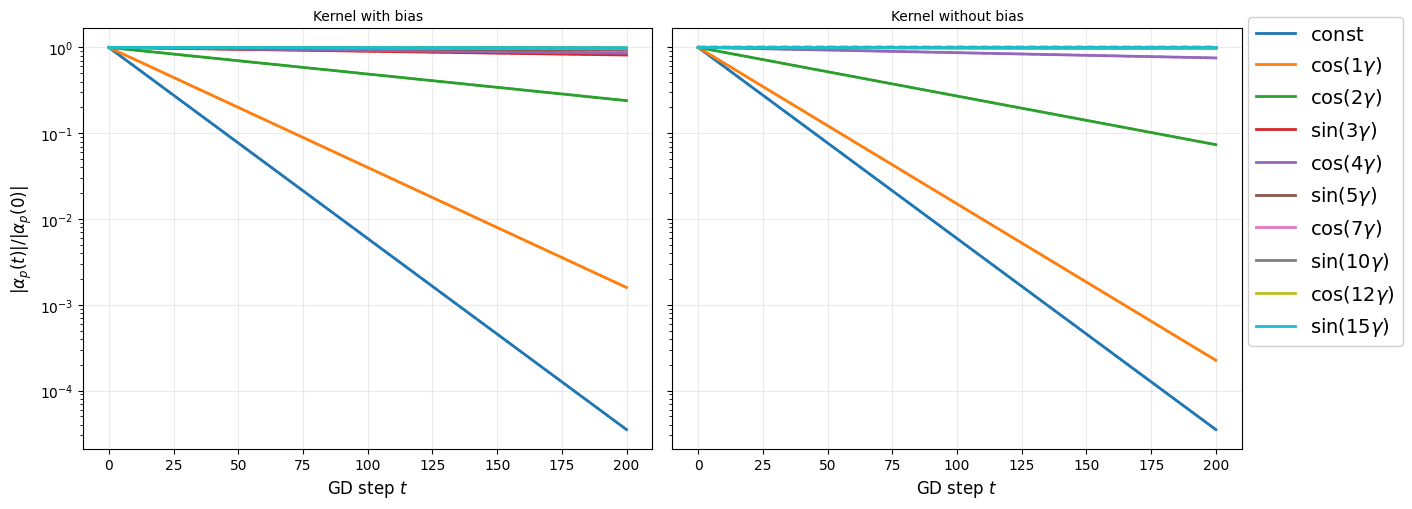

In [17]:
SHORT_WINDOW = 200
man_bias = load_manifest(RUN_THEORY_BIAS)
mode_bias = npz(RUN_THEORY_BIAS, man_bias["mode_projections"])
kdyn_bias = npz(RUN_THEORY_BIAS, man_bias["kernel_dynamics"])
cont_bias = npz(RUN_THEORY_BIAS, man_bias["continuum_spectrum"])

man_nb = load_manifest(RUN_THEORY_NO_BIAS)
mode_nb = npz(RUN_THEORY_NO_BIAS, man_nb["mode_projections"])
kdyn_nb = npz(RUN_THEORY_NO_BIAS, man_nb["kernel_dynamics"])
cont_nb = npz(RUN_THEORY_NO_BIAS, man_nb["continuum_spectrum"])

eta_bias = float(np.ravel(kdyn_bias["eta"])[0])
lam_map_bias = {
    int(k): float(v)
    for k, v in zip(
        np.asarray(cont_bias["ks_compare"], dtype=int),
        np.asarray(cont_bias["lambda_disc_pred"], dtype=float),
    )
}

eta_nb = float(np.ravel(kdyn_nb["eta"])[0])
lam_map_nb = {
    int(k): float(v)
    for k, v in zip(
        np.asarray(cont_nb["ks_compare"], dtype=int),
        np.asarray(cont_nb["lambda_disc_pred"], dtype=float),
    )
}

bias_keys = choose_target_mode_keys(
    man_bias["meta"]["target_Ks"],
    man_bias["meta"]["target_phases"],
)

all_modes = sorted(set(bias_keys), key=mode_sort_key)
default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
mode_to_color = {m: default_cycle[i % len(default_cycle)] for i, m in enumerate(all_modes)}

print(bias_keys)
bias_keys = [k for k in bias_keys if mode_key_to_k(k) <= 15]

nb_keys = choose_target_mode_keys(
    man_nb["meta"]["target_Ks"],
    man_nb["meta"]["target_phases"],
)
nb_odd_keys = bias_keys #[k for k in nb_keys if mode_key_to_k(k) in {3, 7, 15}]

print("Bias components shown (k<=7):", bias_keys)
print("No-bias odd components shown:", nb_odd_keys)

tlen = SHORT_WINDOW + 1
steps = np.arange(tlen)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2), sharey=True)

# Left: bias kernel, components up to k=7
ax = axes[0]
for key in bias_keys:
    c = mode_to_color[key]
    source_key = "cos_0" if key == "const" else key
    obs = normalized_abs_curve(mode_bias[source_key])[:tlen]
    lam = lam_map_bias[mode_key_to_k(key)]
    pred = expected_normalized_curve(eta_bias, lam, tlen)

    line, = ax.plot(steps, obs, linewidth=2.0, label=component_label(key), color=c)
    ax.plot(steps, pred, linestyle="--", linewidth=1.6, color=c, alpha=0.95)

ax.set_title(r"Kernel with bias", fontsize=10)
ax.set_xlabel(r"GD step $t$", fontsize=12)
ax.set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$", fontsize=12)
ax.set_yscale("log")
ax.grid(True, alpha=0.25)
# ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.92)

# Right: no-bias kernel odd k=3,7
ax = axes[1]
for key in nb_odd_keys:
    c = mode_to_color[key]
    source_key = "cos_0" if key == "const" else key
    obs = normalized_abs_curve(mode_nb[source_key])[:tlen]
    lam = lam_map_nb[mode_key_to_k(key)]
    pred = expected_normalized_curve(eta_nb, lam, tlen)

    line, = ax.plot(steps, obs, linewidth=2.0, label=component_label(key), color=c)
    ax.plot(steps, pred, linestyle="--", linewidth=1.6, color=c, alpha=0.95)

ax.set_title(r"Kernel without bias", fontsize=10)
ax.set_xlabel(r"GD step $t$", fontsize=12)
ax.set_yscale("log")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=14, framealpha=0.92, bbox_to_anchor=(1.3, 1.05))

# fig.suptitle(r"Spectral-bias evidence in the first 200 steps", y=1.02)
fig.tight_layout()

out = plot_path / "story_01_spectral_bias_two_panel_first200.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved {out}")
plt.show()
plt.close(fig)

['const', 'cos_1', 'cos_2', 'sin_3', 'cos_4', 'sin_5', 'cos_7', 'sin_10', 'cos_12', 'sin_15']
Bias components shown (k<=7): ['sin_3', 'sin_5', 'cos_7', 'sin_15']
No-bias odd components shown: ['sin_3', 'sin_5', 'cos_7', 'sin_15']
Saved plots/kernel_story_consistent_target/story_01_spectral_bias_two_panel_high_freq_odd.png


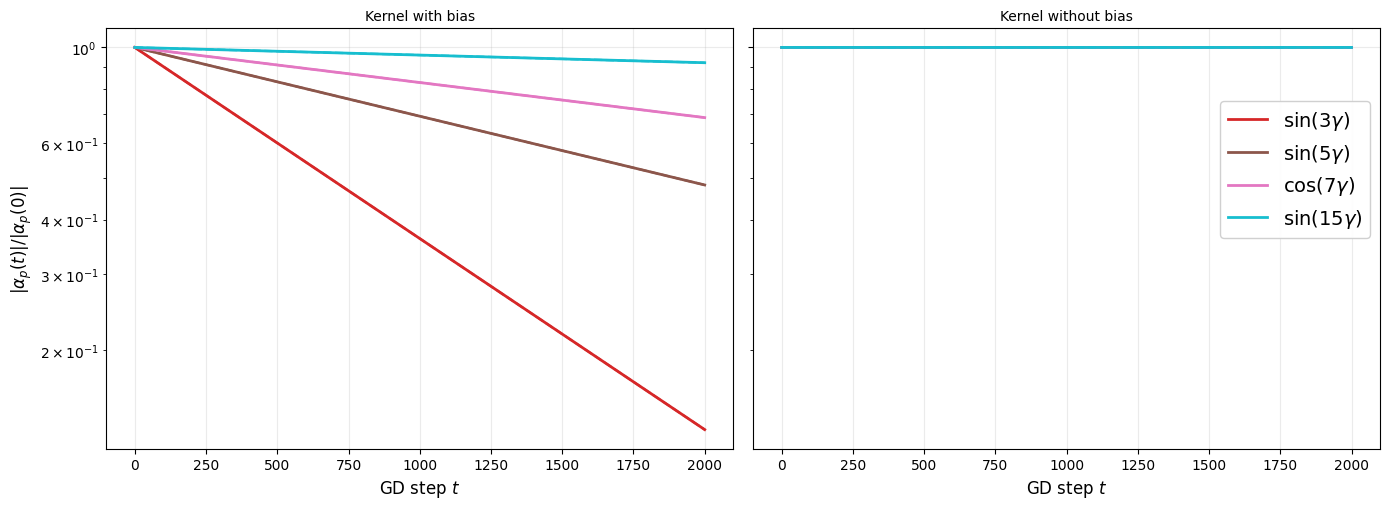

In [18]:
SHORT_WINDOW = 2000

eta_bias = float(np.ravel(kdyn_bias["eta"])[0])
lam_map_bias = {
    int(k): float(v)
    for k, v in zip(
        np.asarray(cont_bias["ks_compare"], dtype=int),
        np.asarray(cont_bias["lambda_disc_pred"], dtype=float),
    )
}

eta_nb = float(np.ravel(kdyn_nb["eta"])[0])
lam_map_nb = {
    int(k): float(v)
    for k, v in zip(
        np.asarray(cont_nb["ks_compare"], dtype=int),
        np.asarray(cont_nb["lambda_disc_pred"], dtype=float),
    )
}

bias_keys = choose_target_mode_keys(
    man_bias["meta"]["target_Ks"],
    man_bias["meta"]["target_phases"],
)
print(bias_keys)
bias_keys = [k for k in bias_keys if mode_key_to_k(k) >= 3 and mode_key_to_k(k) % 2 == 1]

nb_keys = choose_target_mode_keys(
    man_nb["meta"]["target_Ks"],
    man_nb["meta"]["target_phases"],
)
nb_odd_keys = bias_keys #[k for k in nb_keys if mode_key_to_k(k) in {3, 7, 15}]

print("Bias components shown (k<=7):", bias_keys)
print("No-bias odd components shown:", nb_odd_keys)

tlen = SHORT_WINDOW + 1
steps = np.arange(tlen)

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2), sharey=True)

# Left: bias kernel, components up to k=7
ax = axes[0]
for key in bias_keys:
    c = mode_to_color[key]
    source_key = "cos_0" if key == "const" else key
    obs = normalized_abs_curve(mode_bias[source_key])[:tlen]
    lam = lam_map_bias[mode_key_to_k(key)]
    pred = expected_normalized_curve(eta_bias, lam, tlen)

    line, = ax.plot(steps, obs, linewidth=2.0, label=component_label(key), color=c)
    ax.plot(steps, pred, linestyle="--", linewidth=1.6, color=c, alpha=0.95)

ax.set_title(r"Kernel with bias", fontsize=10)
ax.set_xlabel(r"GD step $t$", fontsize=12)
ax.set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$", fontsize=12)
ax.set_yscale("log")
ax.grid(True, alpha=0.25)
# ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.92)

# Right: no-bias kernel odd k=3,7
ax = axes[1]
for key in nb_odd_keys:
    c = mode_to_color[key]
    source_key = "cos_0" if key == "const" else key
    obs = normalized_abs_curve(mode_nb[source_key])[:tlen]
    lam = lam_map_nb[mode_key_to_k(key)]
    pred = expected_normalized_curve(eta_nb, lam, tlen)

    line, = ax.plot(steps, obs, linewidth=2.0, label=component_label(key), color=c)
    ax.plot(steps, pred, linestyle="--", linewidth=1.6, color=c, alpha=0.95)

ax.set_title(r"Kernel without bias", fontsize=10)
ax.set_xlabel(r"GD step $t$", fontsize=12)
ax.set_yscale("log")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=14, framealpha=0.92, bbox_to_anchor=(1.0, 0.85))

# fig.suptitle(r"Spectral-bias evidence in the first 200 steps", y=1.02)
fig.tight_layout()

out = plot_path / "story_01_spectral_bias_two_panel_high_freq_odd.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved {out}")
plt.show()
plt.close(fig)

In [24]:
# Load and combine random-sampling runs from both experiments
man_rand_large = load_manifest(RUN_RANDOM)
man_rand_small = load_manifest(RUN_RANDOM_SMALL)

by_n_large = build_runs_by_n(RUN_RANDOM, man_rand_large)
by_n_small = build_runs_by_n(RUN_RANDOM_SMALL, man_rand_small)

by_n = {}
for source in (by_n_small, by_n_large):
    for n, runs in source.items():
        by_n.setdefault(n, []).extend(runs)

by_n = {n: by_n[n] for n in sorted(by_n.keys())}
man_rand = man_rand_large

print("Combined n values:", sorted(by_n.keys()))
print("Runs per n:", {n: len(v) for n, v in by_n.items()})

Combined n values: [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
Runs per n: {128: 10, 256: 10, 512: 10, 1024: 10, 2048: 10, 4096: 10, 8192: 10, 16384: 10, 32768: 10}


## 2) Random sampling: n=32768, mean ± std across seeds (first 200 steps)

['const', 'cos_1', 'cos_2', 'sin_3', 'cos_7']
Using n=4096, runs=10
Modes shown: ['const', 'cos_1', 'cos_2', 'sin_3', 'cos_7']
Saved plots/kernel_story_consistent_target/story_02_random_n4096_components_first200.png


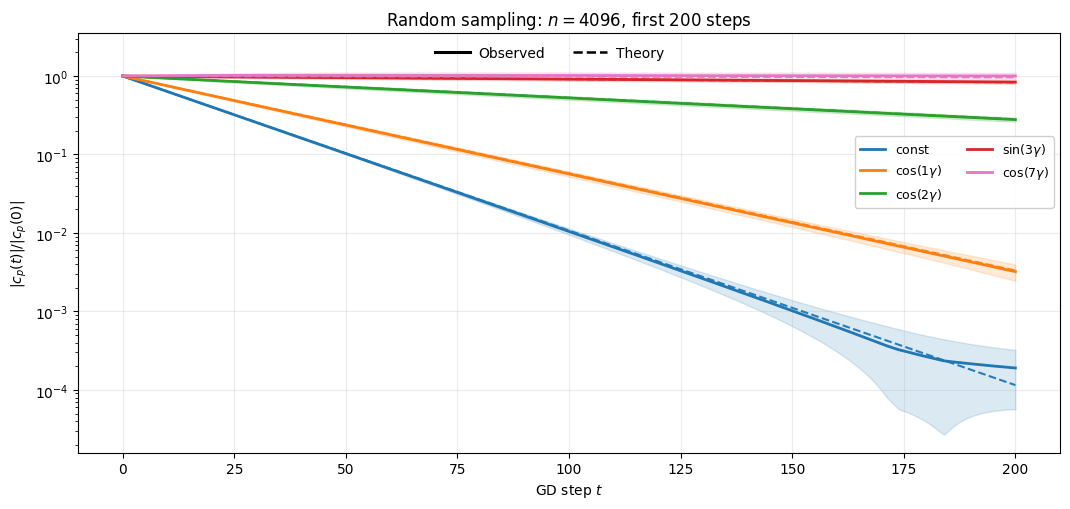

In [ ]:
from matplotlib.lines import Line2D


SHORT_WINDOW = 200
n_show = 4096 #max(by_n.keys())

mode_names, base_stack = stack_curves_for_n(by_n, n_show, "mode_curves_base")
name_to_idx = {name: i for i, name in enumerate(mode_names)}

target_mode_keys = choose_target_mode_keys(
    man_rand["meta"]["target_Ks"],
    man_rand["meta"]["target_phases"],
)

print(target_mode_keys)
modes_to_plot = [m for m in target_mode_keys if m in name_to_idx]

print(f"Using n={n_show}, runs={len(by_n[n_show])}")
print("Modes shown:", modes_to_plot)

tlen = min(SHORT_WINDOW + 1, base_stack.shape[1])
steps = np.arange(tlen)

fig, ax = plt.subplots(figsize=(10.8, 5.2))

for mode_name in modes_to_plot:
    c = mode_to_color[mode_name]
    j = name_to_idx[mode_name]
    obs_stack = np.clip(base_stack[:, :tlen, j], EPS, None)
    obs_mean = obs_stack.mean(axis=0)
    obs_std = obs_stack.std(axis=0)

    # Expected normalized decay from each run's eta and lambda_n_diag
    pred_runs = []
    for run in by_n[n_show]:
        lam_diag = np.asarray(run["lambda_n_diag"], dtype=float)
        eta = float(np.ravel(run["eta"])[0])
        pred_runs.append(expected_normalized_curve(eta, lam_diag[j], tlen))
    pred_mean = np.mean(np.asarray(pred_runs), axis=0)

    line, = ax.plot(steps, obs_mean, linewidth=2.0, label=component_label(mode_name), color=c)
    lower = np.clip(obs_mean - obs_std, EPS, None)
    upper = np.clip(obs_mean + obs_std, EPS, None)
    ax.fill_between(steps, lower, upper, color=c, alpha=0.16)
    ax.plot(steps, pred_mean, linestyle="--", linewidth=1.5, color=c, alpha=0.95)

ax.set_yscale("log")
ax.set_ylim(top=3.5)
ax.set_xlabel(r"GD step $t$")
ax.set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
ax.set_title(rf"Random sampling: $n={n_show}$, first {SHORT_WINDOW} steps")
ax.grid(True, alpha=0.25)
main_legend = ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.92, bbox_to_anchor=(1.0, 0.77))

style_elements = [
    Line2D([0], [0], color='black', linestyle='-',  lw=2.2, label='Observed'),
    Line2D([0], [0], color='black', linestyle='--', lw=1.8, label='Theory'),
]

# This places the style legend nicely just below the title, centered or slightly to the right
style_legend = ax.legend(
    handles=style_elements,
    title=None,
    loc='upper center',
    bbox_to_anchor=(0.48, 1.0),   
    ncol=2,
    fontsize=10,
    frameon=False,                
    handlelength=2.5,
    handletextpad=0.6
)

ax.add_artist(main_legend)

fig.tight_layout()
out = plot_path / f"story_02_random_n{n_show}_components_first200.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved {out}")
plt.show()
plt.close(fig)

['const', 'cos_1', 'cos_2', 'sin_3', 'cos_7']
Using n=4096, runs=10
Modes shown: ['cos_2', 'sin_3', 'cos_7']
Saved plots/kernel_story_consistent_target/story_02_random_n4096_components_all_steps_high_freq_only.png


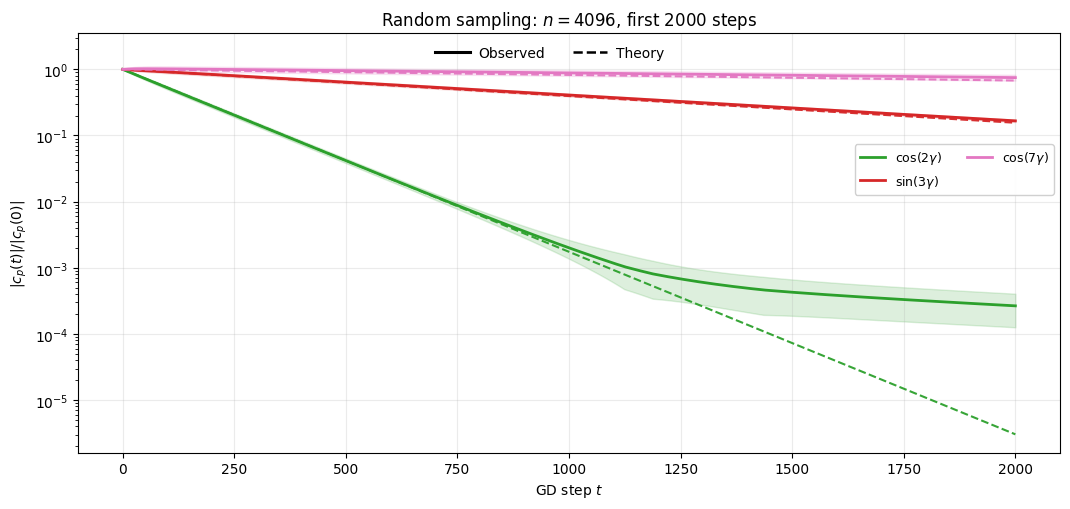

In [ ]:
SHORT_WINDOW = 2000

mode_names, base_stack = stack_curves_for_n(by_n, n_show, "mode_curves_base")
name_to_idx = {name: i for i, name in enumerate(mode_names)}

target_mode_keys = choose_target_mode_keys(
    man_rand["meta"]["target_Ks"],
    man_rand["meta"]["target_phases"],
)

print(target_mode_keys)
modes_to_plot = [m for m in target_mode_keys if m in name_to_idx and mode_key_to_k(m) >= 2]

print(f"Using n={n_show}, runs={len(by_n[n_show])}")
print("Modes shown:", modes_to_plot)

tlen = min(SHORT_WINDOW + 1, base_stack.shape[1])
steps = np.arange(tlen)

fig, ax = plt.subplots(figsize=(10.8, 5.2))

for mode_name in modes_to_plot:
    c = mode_to_color[mode_name]
    j = name_to_idx[mode_name]
    obs_stack = np.clip(base_stack[:, :tlen, j], EPS, None)
    obs_mean = obs_stack.mean(axis=0)
    obs_std = obs_stack.std(axis=0)

    # Expected normalized decay from each run's eta and lambda_n_diag
    pred_runs = []
    for run in by_n[n_show]:
        lam_diag = np.asarray(run["lambda_n_diag"], dtype=float)
        eta = float(np.ravel(run["eta"])[0])
        pred_runs.append(expected_normalized_curve(eta, lam_diag[j], tlen))
    pred_mean = np.mean(np.asarray(pred_runs), axis=0)

    line, = ax.plot(steps, obs_mean, linewidth=2.0, label=component_label(mode_name), color=c)
    lower = np.clip(obs_mean - obs_std, EPS, None)
    upper = np.clip(obs_mean + obs_std, EPS, None)
    ax.fill_between(steps, lower, upper, color=c, alpha=0.16)
    ax.plot(steps, pred_mean, linestyle="--", linewidth=1.5, color=c, alpha=0.95)

ax.set_yscale("log")
ax.set_ylim(top=3.5)
ax.set_xlabel(r"GD step $t$")
ax.set_ylabel(r"$|\alpha_p(t)| / |\alpha_p(0)|$")
ax.set_title(rf"Random sampling: $n={n_show}$, first {SHORT_WINDOW} steps")
ax.grid(True, alpha=0.25)
main_legend = ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.92, bbox_to_anchor=(1.0, 0.75))

style_elements = [
    Line2D([0], [0], color='black', linestyle='-',  lw=2.2, label='Observed'),
    Line2D([0], [0], color='black', linestyle='--', lw=1.8, label='Theory'),
]

# This places the style legend nicely just below the title, centered or slightly to the right
style_legend = ax.legend(
    handles=style_elements,
    title=None,
    loc='upper center',
    bbox_to_anchor=(0.48, 1.0),   
    ncol=2,
    fontsize=10,
    frameon=False,                
    handlelength=2.5,
    handletextpad=0.6
)

ax.add_artist(main_legend)

fig.tight_layout()
out = plot_path / f"story_02_random_n{n_show}_components_all_steps_high_freq_only.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved {out}")
plt.show()
plt.close(fig)

## 3) High-frequency sample-size effect: k across n (first 200 steps)

['const', 'cos_1', 'cos_2', 'sin_3', 'cos_7']
High-frequency mode shown: cos_1
n values: [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
Saved plots/kernel_story_consistent_target/story_03_random_high_k1_across_n_first200.png


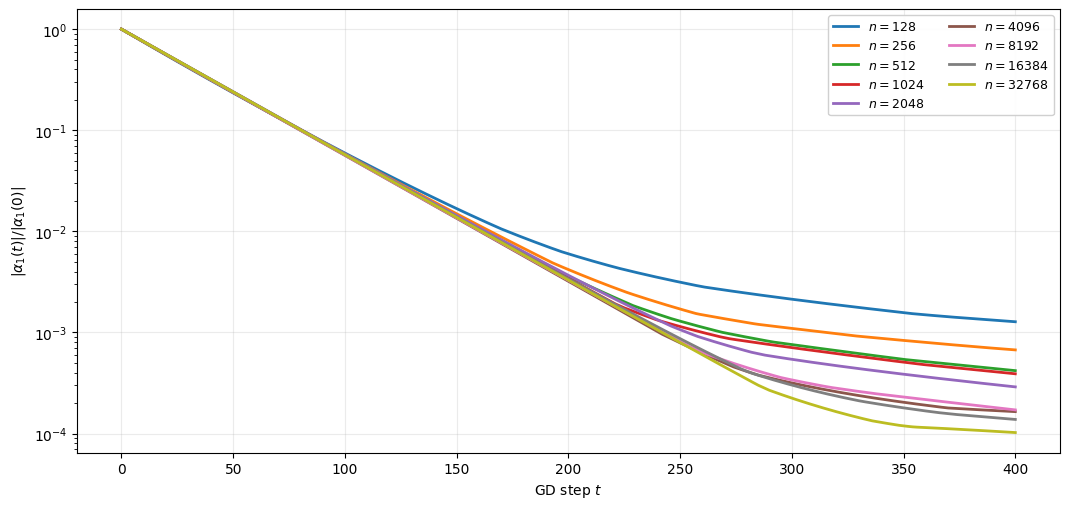

In [52]:
SHORT_WINDOW = 400
n_values = sorted(by_n.keys())
print(target_mode_keys)

k = 1

high_mode_candidates = [m for m in target_mode_keys if mode_key_to_k(m) == k and m in name_to_idx]
if not high_mode_candidates:
    raise KeyError("No target mode with k=7 found in random-sampling runs.")
high_mode = high_mode_candidates[0]
j_high = name_to_idx[high_mode]

print("High-frequency mode shown:", high_mode)
print("n values:", n_values)

fig, ax = plt.subplots(figsize=(10.8, 5.2))

for n_train in n_values:
    _, stack_n = stack_curves_for_n(by_n, n_train, "mode_curves_base")
    tlen = min(SHORT_WINDOW + 1, stack_n.shape[1])
    steps = np.arange(tlen)

    curves = np.clip(stack_n[:, :tlen, j_high], EPS, None)
    mean = curves.mean(axis=0)
    std = curves.std(axis=0)

    line, = ax.plot(steps, mean, linewidth=2.0, label=rf"$n={n_train}$")
    lower = np.clip(mean - std, EPS, None)
    upper = np.clip(mean + std, EPS, None)
    # ax.fill_between(steps, lower, upper, color=line.get_color(), alpha=0.14)

ax.set_yscale("log")
ax.set_xlabel(r"GD step $t$")
ax.set_ylabel(rf"$|\alpha_{k}(t)| / |\alpha_{k}(0)|$")
# ax.set_title(rf"Random sampling high-frequency decay: $k={k}$, first {SHORT_WINDOW} steps")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", ncol=2, fontsize=9, framealpha=0.92)

fig.tight_layout()
out = plot_path / f"story_03_random_high_k{k}_across_n_first200.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved {out}")
plt.show()
plt.close(fig)